In [1]:
# Standard Python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier 
from sklearn.model_selection import train_test_split

# Global variables
import warnings
warnings.filterwarnings("ignore")

start_year = 1993

In [2]:
# Custom API
from sys import path

path.append('../')
from API.get_curr_year import curr_year
from API.eda.data_visualizations import get_yearly_base_rates, get_seed_pairs, format_plot
import API.fetch.data_fetch as fetch
from API.model.model_selection import get_cv_models
from API.model.model_evaluation import evaluate_cv_models, model_predictions, get_classification_report
from API.preprocess.feature_engineering import create_bracket_winners
from API.preprocess.data_integrity import season_team_to_coach_team_dict
from API.preprocess.data_clean import clean_basic_stats, clean_tourney_data
from API.preprocess.data_pipeline import dataset_pipeline, feature_pipeline, bracket_pipeline

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)
Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)
Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)
Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


# Data Fetching

## Examples

### Team Regular Season Stats

In [3]:
basic_stats_df = fetch.get_team_data(url=f"https://www.sports-reference.com/cbb/seasons/{curr_year}-school-stats.html",
                                     attrs={'id': 'basic_school_stats'})
basic_stats_df.head()

,Rk,School,G,W,L,W-L%,SRS,SOS,Unnamed: 8,W.1,...,FT,FTA,FT%,ORB,TRB,AST,STL,BLK,TOV,PF
0,1,Abilene Christian,33,14,19,.424,-7.18,-1.25,NaN,5,...,522,741,.704,369,1047,440,321,91,472,691
1,2,Air Force,32,3,29,.094,-13.66,4.68,NaN,0,...,368,574,.641,225,931,389,180,76,472,570
2,3,Akron NCAA,34,29,5,.853,9.04,-3.33,NaN,17,...,453,601,.754,386,1294,627,256,105,372,536
3,4,Alabama NCAA,32,23,9,.719,22.70,14.45,NaN,13,...,600,784,.765,391,1300,516,206,162,313,593
4,5,Alabama A&M,33,18,15,.545,-12.99,-10.49,NaN,10,...,596,808,.738,311,1126,387,198,93,376,607


In [4]:
adv_stats_df = fetch.get_team_data(url=f"https://www.sports-reference.com/cbb/seasons/{curr_year}-advanced-school-stats.html", 
                                   attrs={'id': 'adv_school_stats'})
adv_stats_df.head()

,Rk,School,G,W,L,W-L%,SRS,SOS,Unnamed: 8,W.1,...,3PAr,TS%,TRB%,AST%,STL%,BLK%,eFG%,TOV%,ORB%,FT/FGA
0,1,Abilene Christian,33,14,19,.424,-7.18,-1.25,NaN,5,...,.328,.529,50.4,54.7,14.0,8.1,.489,17.7,32.6,.284
1,2,Air Force,32,3,29,.094,-13.66,4.68,NaN,0,...,.418,.516,44.8,55.9,8.3,6.8,.489,19.8,21.4,.225
2,3,Akron NCAA,34,29,5,.853,9.04,-3.33,NaN,17,...,.451,.612,53.5,57.5,10.5,9.1,.588,13.2,34.0,.209
3,4,Alabama NCAA,32,23,9,.719,22.70,14.45,NaN,13,...,.537,.592,50.4,53.5,8.6,11.3,.554,11.2,31.8,.285
4,5,Alabama A&M,33,18,15,.545,-12.99,-10.49,NaN,10,...,.343,.545,49.9,49.4,8.8,7.9,.496,14.7,28.0,.331


### Coach & Team Performance

In [5]:
coaches_rankings_df = fetch.get_coach_rankings_data(curr_year)
coaches_rankings_df.head()

,Coach_Team,Conf,Top_25,MM,S16,F4,Champs
371,Abilene Christian,WAC,0,,,,
185,Air Force,MWC,0,,,,
131,Akron,MAC,0,7,1,,
278,Alabama,SEC,1,9,4,1,
166,Alabama A&M,SWAC,0,1,,,


### Tournament Game Data

In [6]:
hist_bracket_df = fetch.get_hist_bracket(curr_year-1)
hist_bracket_df.head()

,Year,Round,Seed,Team,Score,Seed.1,Team.1,Score.1
0,2025,Play-In,16,Mount St. Mary's,83,16,American,72
1,2025,Play-In,11,UNC,95,11,San Diego State,68
2,2025,Play-In,16,Saint Francis (PA),68,16,Alabama State,70
3,2025,Play-In,11,Xavier,86,11,Texas,80
4,2025,First Round,1,Duke,93,16,Mount St. Mary's,49


# Data Pipeline

In [7]:
# Check if the historical data CSV exists, if it doesn't then create it
try:
    mm_matchups_df = pd.read_csv(f'{curr_year}_march_madness_hist_data.csv')
except FileNotFoundError:
    mm_matchups_df = dataset_pipeline(np.arange(start_year, curr_year))
    mm_matchups_df.to_csv(f'{curr_year}_march_madness_hist_data.csv', index=False)

mm_matchups_df

,Year,Round,Seed_Favorite,Team_Favorite,Seed_Underdog,Team_Underdog,Underdog_Upset,G_Favorite,W-L%_Favorite,SRS_Favorite,...,eFG%_Underdog,TOV%_Underdog,ORB%_Underdog,FT/FGA_Underdog,Conf_Underdog,Top_25_Underdog,MM_Underdog,S16_Underdog,F4_Underdog,Champs_Underdog
0,1993,First Round,1,UNC,16,East Carolina,0,38,0.895,29.04,...,0.465,17.3,NaN,0.248,CAA,0,1,0,0,0
1,1993,First Round,8,Rhode Island,9,Purdue,0,30,0.633,9.50,...,0.519,18.8,NaN,0.278,Big Ten,1,10,1,0,0
2,1993,First Round,5,St. John's (NY),12,Texas Tech,0,30,0.633,13.14,...,0.530,18.1,NaN,0.304,SWC,0,1,0,0,0
3,1993,First Round,4,Arkansas,13,Holy Cross,0,31,0.710,17.72,...,0.516,16.8,NaN,0.336,Patriot,0,3,0,0,0
4,1993,First Round,6,Virginia,11,Manhattan,0,31,0.677,14.60,...,0.511,19.8,NaN,0.291,MAAC,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2068,2025,Sweet Sixteen,3,Texas Tech,10,Arkansas,0,37,0.757,23.05,...,0.522,14.3,28.1,0.263,SEC,1,24,16,6,1
2069,2025,Elite Eight,1,Florida,3,Texas Tech,0,40,0.900,27.78,...,0.547,12.1,34.2,0.222,Big 12,1,3,1,0,0
2070,2025,Final Four,1,Duke,1,Houston,1,39,0.897,30.72,...,0.517,11.8,36.9,0.201,Big 12,1,21,9,3,0
2071,2025,Final Four,1,Florida,1,Auburn,0,40,0.900,27.78,...,0.549,11.7,34.2,0.247,SEC,1,14,6,2,0


## Handling Missing Values

### Finding the Nulls

In [8]:
# Given that a feature has any nulls, find the number of nulls present
true_nulls = fetch.get_feature_null_counts(mm_matchups_df)
true_nulls

Pace_Favorite    765
STL%_Favorite    765
ORB%_Favorite    765
ORtg_Favorite    765
ORtg_Underdog    764
STL%_Underdog    764
Pace_Underdog    764
ORB%_Underdog    763
ORB_Underdog     255
ORB_Favorite     254
TOV%_Underdog      3
TOV_Underdog       3
TOV_Favorite       1
TOV%_Favorite      1
dtype: int64

In [9]:
# Get turnover features from true_nulls
tov_null_fills = [col for col in true_nulls.index if ('TOV' in col)]

# All other features found in true_nulls are dropped from our original dataset
null_drops = list(set(true_nulls.index) - set(tov_null_fills))
mm_matchups_df.drop(null_drops, axis=1, inplace=True)

In [10]:
# View the rows containing all of the dataset's nulls to be imputed
# This will be a useful reference to validate the proper imputation of the nulls
tov_nulls_rows = fetch.get_null_rows(tov_null_fills, mm_matchups_df)
display(tov_nulls_rows)

,Year,TOV%_Underdog,TOV_Underdog,TOV_Favorite,TOV%_Favorite,Underdog_Upset
47,1993,NaN,NaN,373.0,15.9,1
54,1993,16.6,552.0,NaN,NaN,0
57,1993,NaN,NaN,561.0,17.4,0
470,2000,NaN,NaN,520.0,17.8,0


### What are the Distributions of the Features We Wish to Impute?

1993 feature distributions
2000 feature distributions


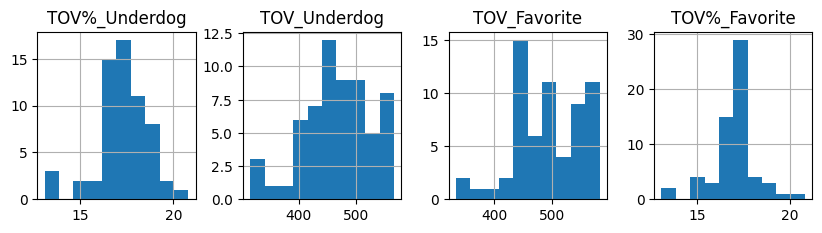

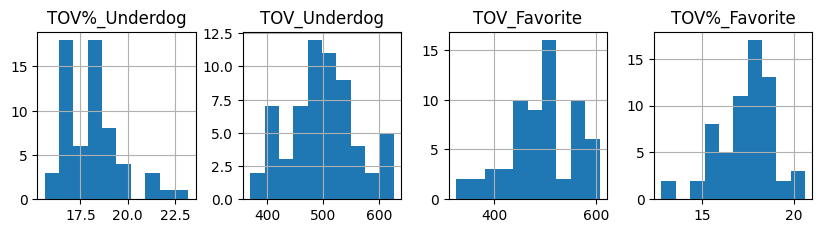

In [11]:
# View the distributions of the dataset's turnover features
tov_null_years = sorted(list(set(tov_nulls_rows['Year'])))

for year in tov_null_years:
    print(f"{year} feature distributions")
    year_df = mm_matchups_df[mm_matchups_df['Year'] == year]
    year_df[tov_null_fills].hist(figsize=(10, 5), layout=(len(tov_null_years), len(tov_null_fills)))

### Impute TOV Nulls by Season & Target Variable

In [12]:
# Retrieve TOV feature means by season; only include seasons that contain nulls
tov_col_means = mm_matchups_df[tov_nulls_rows.columns].groupby(['Year', 'Underdog_Upset']).mean()
tov_col_means.loc[tov_null_years]

TOV%_Underdog  TOV_Underdog  TOV_Favorite  TOV%_Favorite
Year Underdog_Upset                                                          
1993 0                   17.360000    463.044444    496.666667      16.984444
     1                   17.056250    475.937500    481.941176      17.282353
2000 0                   18.336364    492.704545    507.733333      17.511111
     1                   17.544444    511.000000    468.944444      17.066667

In [13]:
for year in tov_null_years:
    for label in [0, 1]:
        for col in tov_null_fills:
            # Get feature's rows with nulls for given year & label type
            fill_condition = (tov_nulls_rows['Year'] == year) & (tov_nulls_rows['Underdog_Upset'] == label)
            col_fill_rows = tov_nulls_rows[fill_condition].index
            # Get feature's mean for given year
            col_year_mean = np.round(tov_col_means.loc[(year, label), col], 1)
            # Impute nulls of interest
            mm_matchups_df.loc[col_fill_rows, col] = mm_matchups_df.loc[col_fill_rows, col].fillna(col_year_mean)

# Display rows that originally had nulls to see if they match discovered feature means
mm_matchups_df.loc[tov_nulls_rows.index, tov_null_fills]

,TOV%_Underdog,TOV_Underdog,TOV_Favorite,TOV%_Favorite
47,17.1,475.9,373.0,15.9
54,16.6,552.0,496.7,17.0
57,17.4,463.0,561.0,17.4
470,18.3,492.7,520.0,17.8


# Exploratory Data Analysis (EDA)

## What is our Bracket's Accuracy if We Guess the Favorite Always Wins?

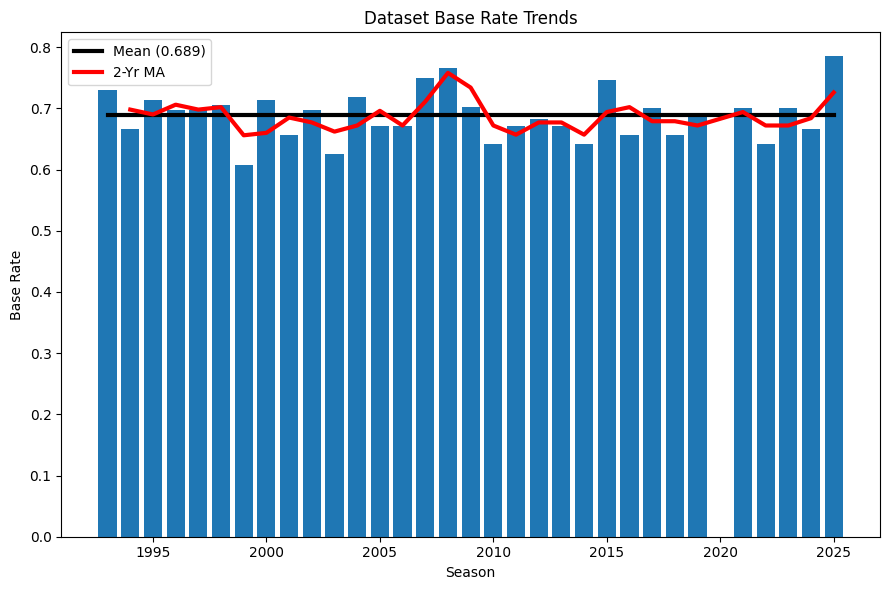

In [14]:
# Each season's base rate
yearly_base_rates = get_yearly_base_rates(mm_matchups_df)
# Dataset's mean base rate
mean_base_rate = np.round(yearly_base_rates.mean(), 3)
# Moving average
years_ma = 2
base_rate_ma = np.round(yearly_base_rates.rolling(years_ma).mean(), 3)

# Plot findings
plt.figure(figsize=(9, 6))

plt.plot(yearly_base_rates.index, [mean_base_rate] * len(yearly_base_rates), color='k', linewidth=3, label=f'Mean ({mean_base_rate})')
plt.plot(yearly_base_rates.index, base_rate_ma, color='r', linewidth=3, label=f'{years_ma}-Yr MA')
plt.bar(yearly_base_rates.index, yearly_base_rates)

format_plot(title='Dataset Base Rate Trends', xlabel='Season', ylabel='Base Rate')

## How Often Do Upsets Occur in a Given Year's March Madness?

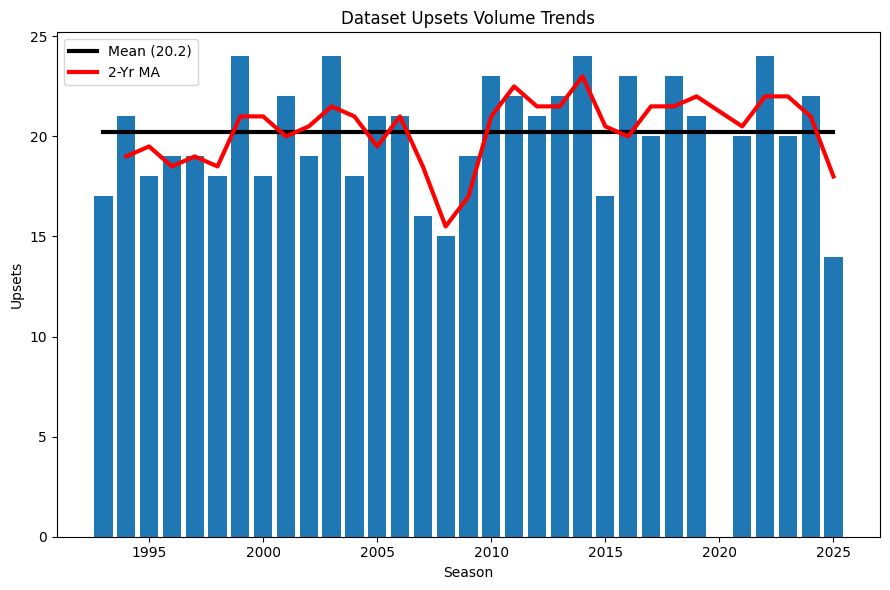

In [15]:
# Each season's upset count
yearly_upsets = mm_matchups_df.groupby('Year').agg({'Underdog_Upset': 'sum'})
# Dataset's mean upset count
mean_upsets = np.round(yearly_upsets['Underdog_Upset'].mean(), 1)
# Moving average
upsets_ma = np.round(yearly_upsets.rolling(years_ma).mean(), 1)

# Plot findings
plt.figure(figsize=(9, 6))

plt.plot(yearly_upsets.index, [mean_upsets] * len(yearly_upsets), color='k', linewidth=3, label=f'Mean ({mean_upsets})')
plt.plot(yearly_upsets.index, upsets_ma, color='r', linewidth=3, label=f'{years_ma}-Yr MA')
plt.bar(yearly_upsets.index, yearly_upsets['Underdog_Upset'])

format_plot(title='Dataset Upsets Volume Trends', xlabel='Season', ylabel='Upsets')

## What is the Distribution of Upsets Across the Tournament Rounds?

In [16]:
# Retrieve data about March Madness matchup seed pairings
seed_pairs = get_seed_pairs(mm_matchups_df)
# Extract seed pairs that resulted in upsets
upset_pairs = seed_pairs[seed_pairs['Underdog_Upset'] == 1]

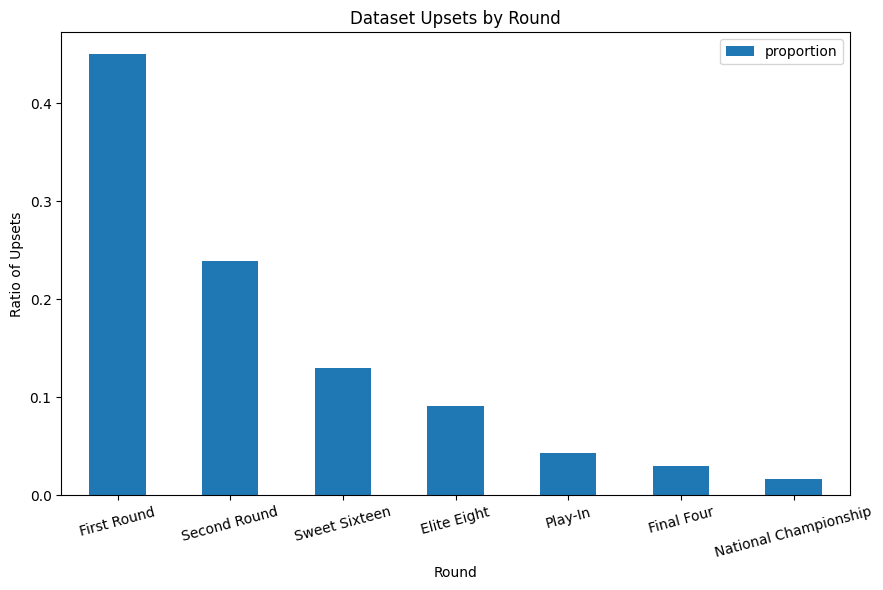

In [17]:
# Group upset seed pairs by round and count them
upset_rounds_freq = upset_pairs['Round'].value_counts(normalize=True)

# Plot findings
upset_rounds_freq.plot(figsize=(9, 6), kind='bar', rot=15)

format_plot(title='Dataset Upsets by Round', xlabel='Round', ylabel='Ratio of Upsets')

## Which Seeding Combinations are the Most Likely to Produce Upsets?

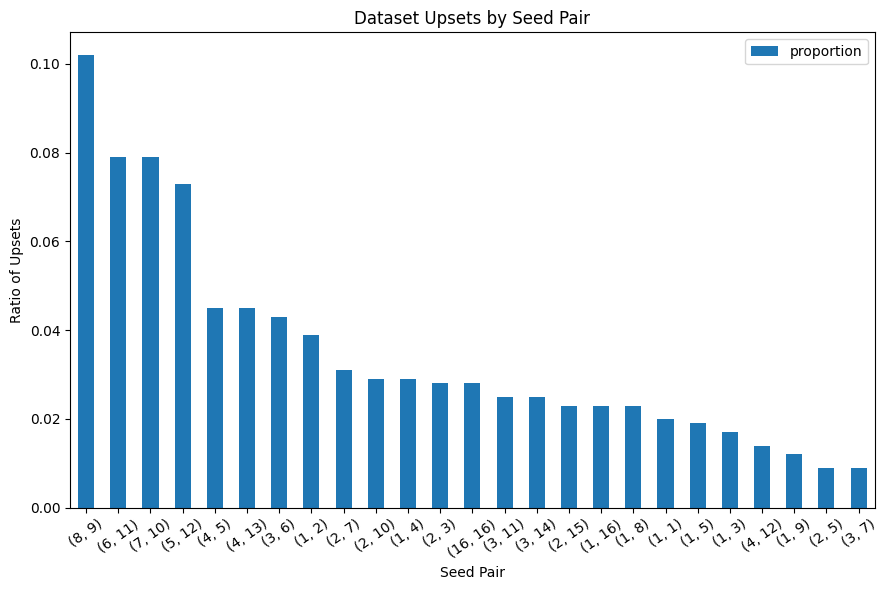

In [18]:
# Group upsets by seed pairing and count them
upset_pairs_freq = np.round(upset_pairs['Pairs'].value_counts(normalize=True)[:25], 3)

# Plot findings
upset_pairs_freq.plot(figsize=(9, 6), kind='bar', rot=35)

format_plot(title='Dataset Upsets by Seed Pair', xlabel='Seed Pair', ylabel='Ratio of Upsets')

# Feature Engineering & Analysis

In [19]:
# Drop unneeded features
mm_matchups_df.drop(['Year', 'Team_Favorite', 'Team_Underdog'], axis=1, inplace=True)
# Store rounds data (for EDA visualizations)
all_rounds = mm_matchups_df['Round']

# Create feature matrix and target variable
X = mm_matchups_df.drop('Underdog_Upset', axis=1)
y = mm_matchups_df['Underdog_Upset']

display(X), display(y)

,Round,Seed_Favorite,Seed_Underdog,G_Favorite,W-L%_Favorite,SRS_Favorite,FG_Favorite,FG%_Favorite,3P_Favorite,3P%_Favorite,...,BLK%_Underdog,eFG%_Underdog,TOV%_Underdog,FT/FGA_Underdog,Conf_Underdog,Top_25_Underdog,MM_Underdog,S16_Underdog,F4_Underdog,Champs_Underdog
0,First Round,1,16,38,0.895,29.04,1219,0.506,168,0.372,...,5.9,0.465,17.3,0.248,CAA,0,1,0,0,0
1,First Round,8,9,30,0.633,9.50,787,0.439,161,0.335,...,5.3,0.519,18.8,0.278,Big Ten,1,10,1,0,0
2,First Round,5,12,30,0.633,13.14,825,0.481,80,0.331,...,5.6,0.530,18.1,0.304,SWC,0,1,0,0,0
3,First Round,4,13,31,0.710,17.72,995,0.488,210,0.395,...,5.9,0.516,16.8,0.336,Patriot,0,3,0,0,0
4,First Round,6,11,31,0.677,14.60,847,0.441,140,0.334,...,6.2,0.511,19.8,0.291,MAAC,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2068,Sweet Sixteen,3,10,37,0.757,23.05,1059,0.466,371,0.367,...,15.0,0.522,14.3,0.263,SEC,1,24,16,6,1
2069,Elite Eight,1,3,40,0.900,27.78,1182,0.471,390,0.356,...,8.3,0.547,12.1,0.222,Big 12,1,3,1,0,0
2070,Final Four,1,1,39,0.897,30.72,1129,0.493,394,0.386,...,15.8,0.517,11.8,0.201,Big 12,1,21,9,3,0
2071,Final Four,1,1,40,0.900,27.78,1182,0.471,390,0.356,...,15.8,0.549,11.7,0.247,SEC,1,14,6,2,0


0       0
1       0
2       0
3       0
4       0
       ..
2068    0
2069    0
2070    1
2071    0
2072    0
Name: Underdog_Upset, Length: 2073, dtype: int64

(None, None)

In [20]:
"""We'll stratify the 80-20 split of our training & test datasets according to the target
variable's distribution so our model can learn the trends observed in our EDA"""
# Drop round data because it's already stored in previous notebook cell
X.drop('Round', axis=1, inplace=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, 
                                                    stratify=pd.concat([y, all_rounds], axis=1))

# All datasets will be scaled based on fit found for training dataset
basic_stats_cols = clean_basic_stats(basic_stats_df).columns
data_cuts = {    
    'FULL': X,
    'TRAIN': X_train,
    'TEST': X_test,
}

# Pass datasets through feature pipeline to prep them for model fitting
prep_X_train = feature_pipeline('TRAIN', data_cuts, basic_stats_cols)
prep_X_test = feature_pipeline('TEST', data_cuts, basic_stats_cols)

prep_all_X = pd.concat([prep_X_train, prep_X_test])
prep_all_X

,Seed_Favorite,Seed_Underdog,Underdog_Rel_PF/Game,Underdog_Rel_TRB%,Underdog_Rel_3P/Game,Underdog_Rel_eFG%,Underdog_Rel_AST%,Underdog_Rel_BLK/Game,Underdog_Rel_FG%,Underdog_Rel_Champs,...,Underdog_Rel_TOV/Game,Underdog_Rel_TS%,Underdog_Rel_MM,Underdog_Rel_Top_25,Underdog_Rel_BLK%,Underdog_Rel_3P%,Underdog_Rel_TRB/Game,Underdog_Rel_STL/Game,Conf_Favorite,Conf_Underdog
1710,0.383603,0.512227,0.847441,0.737727,0.438435,0.517601,0.582045,0.428489,0.387915,0.363886,...,0.856060,0.812294,1.685671,-0.838830,1.229796,-0.072461,0.144668,1.281761,9.0,29.0
2045,-0.279256,1.013865,-1.619876,-0.219215,1.214294,0.433968,0.410321,0.060483,-0.062592,0.363886,...,-1.236584,0.419584,-0.054580,-0.838830,-0.354740,0.117420,0.384075,-1.134280,5.0,1.0
624,-0.942116,-2.246781,-0.266831,-0.578068,-0.004913,-0.318725,0.853941,0.489823,-0.448741,1.340137,...,-1.333916,-0.063751,0.380483,1.125548,0.504670,-1.048993,-0.493751,-0.530270,5.0,3.0
1188,-0.942116,1.515503,0.051532,-1.116348,-0.725354,-1.796235,0.281528,1.041830,-1.800261,-3.541119,...,0.077402,-2.057509,-2.338659,-0.838830,1.471505,-1.211749,-0.254344,0.073741,3.0,19.0
279,-0.942116,-1.494324,-0.823967,0.319065,0.105924,-0.541746,0.639287,-0.062185,-0.834889,0.363886,...,-0.993253,-0.335627,0.271717,1.125548,0.182391,-0.831986,-0.759759,-1.033612,9.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1917,-0.942116,-0.491048,-1.221922,-0.637877,-1.722888,-0.095705,-1.020711,-0.552859,0.516631,0.363886,...,-1.625913,-0.093960,0.489249,-0.838830,-0.059318,-0.045335,-2.568614,-0.228265,28.0,10.0
246,0.052173,-0.491048,-0.067854,1.096580,0.715527,0.489723,-0.047609,0.305820,0.387915,0.363886,...,-0.360593,0.117500,-1.033471,-0.838830,0.424100,-0.208091,0.756486,1.130759,7.0,31.0
881,-0.279256,0.261408,-0.505604,-0.009884,-0.780773,-0.625378,-0.548470,-0.798195,-0.287845,-0.612365,...,-0.895921,-1.030422,-0.054580,-0.838830,-0.489022,-0.831986,0.091466,-0.177930,28.0,12.0
303,1.046462,0.010589,1.444373,0.857345,-1.057865,-0.792643,-1.063642,1.961843,-0.287845,1.340137,...,1.586052,-1.362715,2.555796,1.125548,1.740070,-1.048993,2.166329,1.684435,12.0,7.0


### What are the Distributions of all our Features?

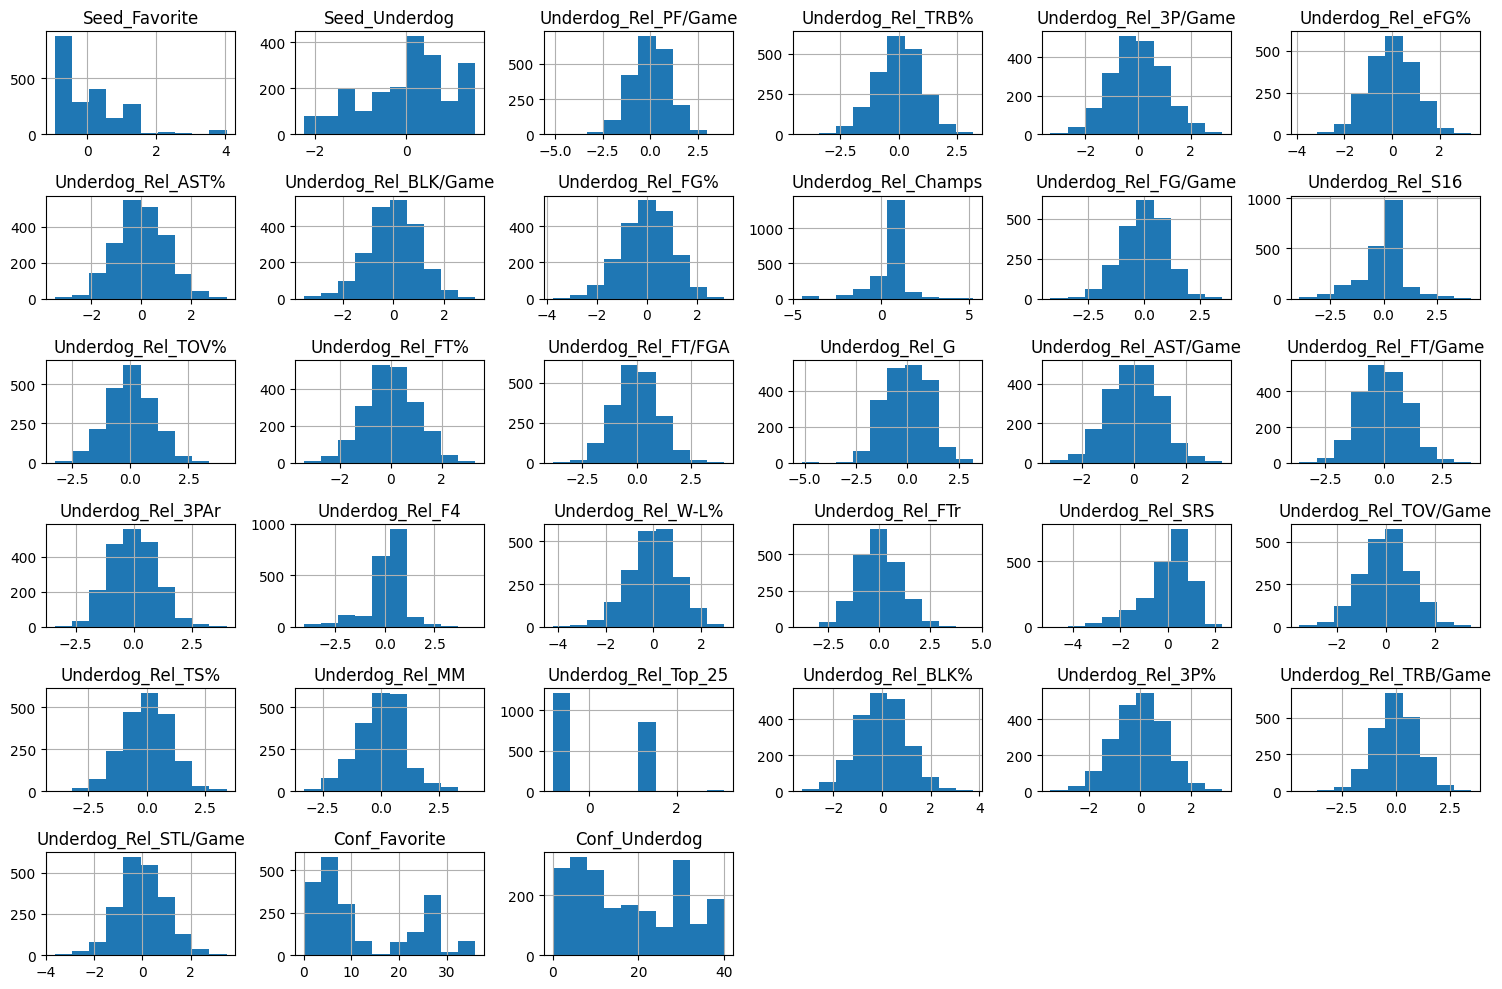

In [21]:
prep_all_X.hist(figsize=(15, 10))
plt.tight_layout()

### What Features have the Greatest Predictive Power?

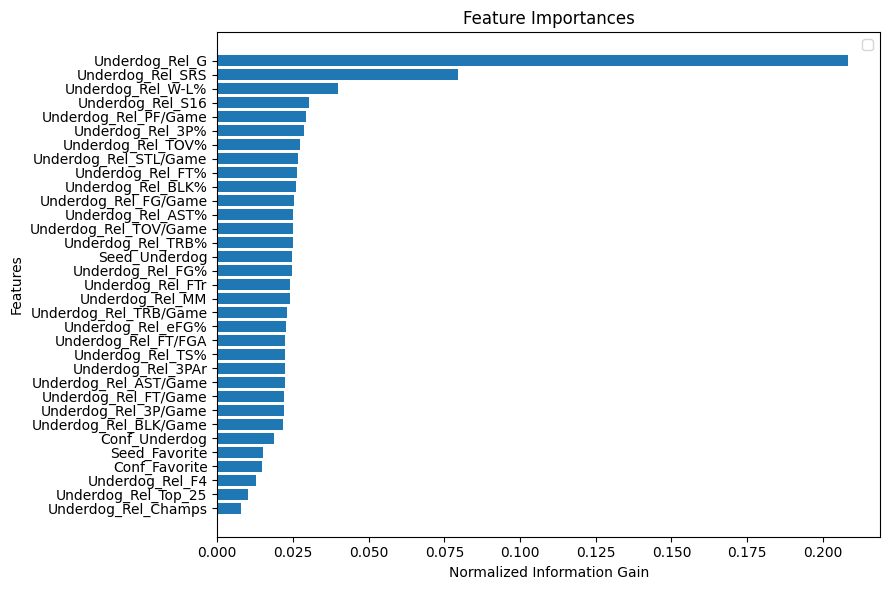

In [22]:
# Fit data to a Random Forest to find feature importances
rf = RandomForestClassifier().fit(prep_X_train, y_train)

# Sort features & their corresponding values in by importance
importances = rf.feature_importances_
feat_importances = prep_all_X.columns[np.argsort(importances)]
feat_values = np.sort(importances)

# Plot findings
plt.figure(figsize=(9, 6))
plt.barh(feat_importances, feat_values)

format_plot(title='Feature Importances', xlabel='Normalized Information Gain', ylabel='Features')

### What are the Correlations Between Features?

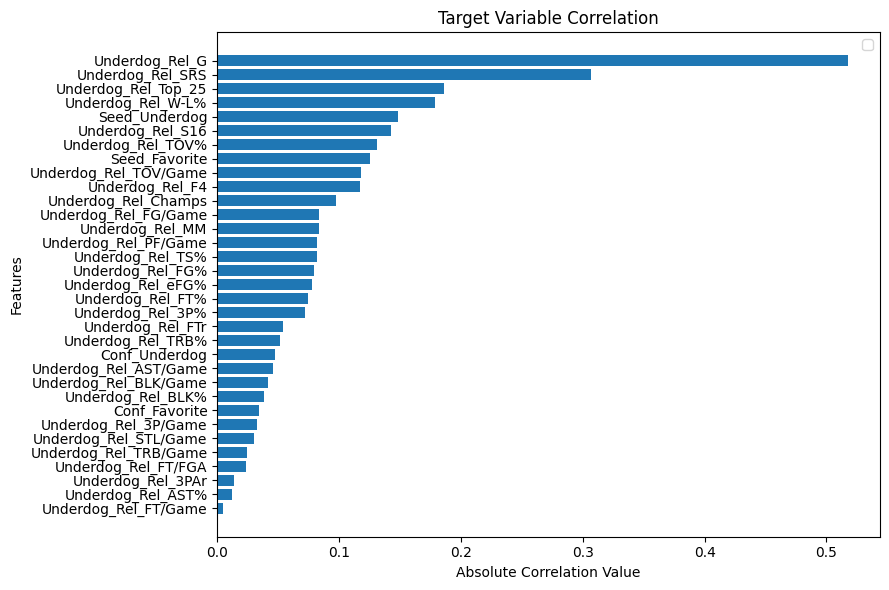

In [23]:
# Get feature matrix's correlations to target variable, then sort by absolute value
prep_X_y = prep_X_train.merge(y_train, left_index=True, right_index=True)
abs_desc_corr = np.abs(prep_X_y.corr().loc['Underdog_Upset']).sort_values()
abs_desc_corr.drop('Underdog_Upset', inplace=True)

# Plot findings
plt.figure(figsize=(9, 6))
plt.barh(abs_desc_corr.index, abs_desc_corr.values)

format_plot(title='Target Variable Correlation', xlabel='Absolute Correlation Value', ylabel='Features')

# Model Selection

### Cross-Validation

In [24]:
%%time

# Perform CV on chosen models with the training set, then assess their respective performances
cv_models = get_cv_models(y)
model_performance = evaluate_cv_models(cv_models, prep_X_train, y_train)
     
model_performance

CPU times: total: 33.6 s
Wall time: 50.7 s


,Best_Mean_Accuracy,Best_Mean_Accuracy_Std
Naive Bayes,0.725,0.021
LogReg,0.812,0.018
SVM,0.809,0.023
Random Forest,0.809,0.007
XGBoost,0.814,0.016


In [25]:
# Identify best model to use
selected_model = 'XGBoost'
best_model = cv_models[selected_model][-1].best_estimator_

best_params = cv_models[selected_model][-1].best_params_
display(best_params)

{'n_estimators': np.int64(91),
 'learning_rate': 0.025,
 'subsample': np.float64(0.1),
 'tree_method': 'gpu_hist',
 'sampling_method': 'gradient_based',
 'lambda': 100,
 'eval_metric': 'error',
 'verbosity': 0,
 'seed': 42}

# Model Evaluation

In [ ]:
# Concatenate all visualization data into a single DataFrame
test_game_data = pd.concat([y_test, all_rounds, mm_matchups_df[['Seed_Favorite', 'Seed_Underdog']]], 
                           join='inner', axis=1).drop('Underdog_Upset', axis=1)

# Overwrite the actual target variable (used for the join) with the best model's predictions
y_preds = model_predictions(best_model, prep_X_test)
test_game_data['Underdog_Upset'] = y_preds

# Get seed pairs data
test_seed_pairs = get_seed_pairs(test_game_data)
# Extract seed pairs that resulted in upsets
test_upset_pairs = test_seed_pairs[test_seed_pairs['Underdog_Upset'] == 1]

In [ ]:
# Group upset seed pairs by round and count them
test_upset_rounds_freq = test_upset_pairs['Round'].value_counts(normalize=True)

# Plot findings
test_upset_rounds_freq.plot(figsize=(9, 6), kind='bar', rot=15)

format_plot(title='Test Set Upsets by Round', xlabel='Round', ylabel='Ratio of Upsets')

In [ ]:
# Group upsets by seed pairing and count them
test_upset_pairs_freq = np.round(test_upset_pairs['Pairs'].value_counts(normalize=True)[:25], 3)

# Plot findings
test_upset_pairs_freq.plot(figsize=(9, 6), kind='bar', rot=35)

format_plot(title='Test Set Upsets by Seed Pair', xlabel='Seed Pair', ylabel='Ratio of Upsets')

In [ ]:
# Show confusion matrix for model's test set predictions
test_set_report = get_classification_report(y_test, y_preds)
print("Test Set Metrics Report \n\n", test_set_report)

# 2026 March Madness Predictions

## Data Pipeline

In [ ]:
# Check if the starting bracket CSV exists, if it doesn't then create it
try:
    curr_bracket_df = pd.read_csv(f'{curr_year}_march_madness_curr_start_bracket.csv')
except FileNotFoundError:
    curr_bracket_df = fetch.get_current_bracket()
    curr_bracket_df.to_csv(f'{curr_year}_march_madness_curr_start_bracket.csv', index=False)
    raise SystemExit("Manually add First Four matchups to starting bracket before resuming program execution")

# Extract play-in matchups
play_in = curr_bracket_df[:4]

# Extract first round matchups
first_round = curr_bracket_df[4:]
first_round.index = range(len(first_round))

display(play_in), display(first_round)

In [ ]:
# Check if bracket predictions have already been generated, otherwise create them
try:
    bracket_preds = pd.read_csv(f'{curr_year}_march_madness_bracket_predictions.csv')
except FileNotFoundError:
    bracket_preds = bracket_pipeline(curr_year, play_in, first_round, best_model, data_cuts, null_drops)
    bracket_preds.to_csv(f'{curr_year}_march_madness_bracket_predictions.csv', index=False)

# Display bracket_pipeline() predictions by round
for _round in bracket_preds['Round'].unique():
    display(bracket_preds[bracket_preds['Round'] == _round])

## Pre-Tournament Model Evaluation (3/18/26)

In [ ]:
# Get seed pairs data
curr_seed_pairs = get_seed_pairs(bracket_preds)
# Extract seed pairs that resulted in upsets
curr_upset_pairs = curr_seed_pairs[curr_seed_pairs['Underdog_Upset'] == 1]

In [ ]:
# Group upset seed pairs by round and count them
curr_upset_rounds_freq = curr_upset_pairs['Round'].value_counts(normalize=True)

# Plot findings
curr_upset_rounds_freq.plot(figsize=(9, 6), kind='bar', rot=0)

format_plot(title='Current Upsets by Round', xlabel='Round', ylabel='Ratio of Upsets')
print(f"Total Upsets: {len(curr_upset_pairs)}")

In [ ]:
# Group upsets by seed pairing and count them
curr_upset_pairs_freq = curr_upset_pairs['Pairs'].value_counts()

# Plot findings
curr_upset_pairs_freq.plot(figsize=(9, 6), kind='bar', rot=35)

format_plot(title='Current Upsets by Seed Pair', xlabel='Seed Pair', ylabel='Ratio of Upsets')

## Post-Tournament Model Evaluation (TBD)

### True Tournament Outcomes EDA

In [ ]:
basic_stats_df = fetch.get_team_data(url=f"https://www.sports-reference.com/cbb/seasons/men/{curr_year}-school-stats.html",
                                     attrs={'id': 'basic_school_stats'})
clean_basic_stats_df = clean_basic_stats(basic_stats_df)

# Clean basic stats' school names to properly merge with raw tournament data
if clean_basic_stats_df['School'].str.contains('NCAA').any():
    clean_basic_stats_df['School'] = clean_basic_stats_df['School'].apply(lambda school: school[:-5])

clean_basic_stats_df['School'].replace(season_team_to_coach_team_dict, inplace=True)

# Create DataFrame (data integrity intact) with all March Madness outcomes
bracket_trues = clean_tourney_data(fetch.get_hist_bracket(curr_year), clean_basic_stats_df)
bracket_trues['Team_Favorite'].replace(season_team_to_coach_team_dict, inplace=True)
bracket_trues['Team_Underdog'].replace(season_team_to_coach_team_dict, inplace=True)

create_bracket_winners(bracket_trues)

# Display true tournament results by round
for _round in bracket_trues['Round'].unique():
    display(bracket_trues[bracket_trues['Round'] == _round])

In [ ]:
# Get seed pairs data
true_seed_pairs = get_seed_pairs(bracket_trues)
# Extract seed pairs that resulted in upsets
true_upset_pairs = true_seed_pairs[true_seed_pairs['Underdog_Upset'] == 1]

In [ ]:
# Group upset seed pairs by round and count them
true_upset_rounds_freq = true_upset_pairs['Round'].value_counts(normalize=True)

# Plot findings
true_upset_rounds_freq.plot(figsize=(9, 6), kind='bar', rot=0)

format_plot(title='True Upsets by Round', xlabel='Round', ylabel='Ratio of Upsets')
print(f"Total Upsets: {len(true_upset_pairs)}")

In [ ]:
# Group upsets by seed pairing and count them
true_upset_pairs_freq = true_upset_pairs['Pairs'].value_counts()

# Plot findings
true_upset_pairs_freq.plot(figsize=(9, 6), kind='bar', rot=35)

format_plot(title='True Upsets by Seed Pair', xlabel='Seed Pair', ylabel='Ratio of Upsets')

### Compare Predicitons to True Outcomes

In [ ]:
# Display correct predictions by round
correct_preds_df = pd.DataFrame(columns=['# Correct Preds', '# Possible Preds'])

for _round in bracket_trues['Round'].unique():
    # Extract round data from predictions & trues
    trues_round = bracket_trues[bracket_trues['Round'] == _round]
    preds_round = bracket_preds[bracket_preds['Round'] == _round]
    
    # Intersection of predictions & trues indicates the model's correct picks
    correct_preds = set(trues_round['Winner']).intersection(set(preds_round['Winner']))
    
    # Input data into Dataframe
    correct_preds_df.loc[_round] = [len(correct_preds), len(preds_round)]
    
correct_preds_df.loc['Tournament Total'] = [correct_preds_df['# Correct Preds'].sum(), correct_preds_df['# Possible Preds'].sum()]
correct_preds_df

In [ ]:
# Calculate and output the model's accuracy
tourney_totals = correct_preds_df.loc['Tournament Total']
print(f"Accuracy: {np.round(tourney_totals['# Correct Preds'] / tourney_totals['# Possible Preds'], 3)}")